# Neural Network Implementation


In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf #pip install tensorflow

# Loading -"MNIST Data Set"
## Containing Training sample = 60,000 , Testing Samples = 10,000
### TensorFlow contains MNIST data set which can be loaded using Keras

In [ ]:
# mnist = tf.keras.datasets.mnist  # Contains the MNIST dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# %cd digits
# %ls



Mounted at /content/drive


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from PIL import Image

# Directory containing your dataset
data_dir = "/content/drive/MyDrive/Colab Notebooks/digits"

# Image dimensions (MNIST standard: 28x28)
img_height, img_width = 28, 28

# Initialize lists for images and labels
images = []
labels = []

# Loop through each folder and load images
for label in sorted(os.listdir(data_dir)):  # Sort ensures labels are in correct order
    label_path = os.path.join(data_dir, label)
    if os.path.isdir(label_path):
        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)
            # Open the image, convert to grayscale, and resize
            img = Image.open(img_path).convert('L').resize((img_width, img_height))
            img_array = np.array(img) / 255.0  # Normalize to [0, 1]
            images.append(img_array)
            labels.append(int(label))  # Use folder name as label

# Convert to numpy arrays
images = np.array(images).reshape(-1, img_height, img_width, 1)  # Add channel dimension
labels = np.array(labels)

# Shuffle dataset
indices = np.arange(len(images))
np.random.shuffle(indices)
images = images[indices]
labels = labels[indices]

# Convert labels to one-hot encoding (if needed for training)
labels_one_hot = to_categorical(labels, num_classes=10)

# Optionally, split into training and test sets
split_idx = int(0.8 * len(images))
x_train, x_test = images[:split_idx], images[split_idx:]
y_train, y_test = labels_one_hot[:split_idx], labels_one_hot[split_idx:]

# Print shapes
print("Training data shape:", x_train.shape, y_train.shape)
print("Test data shape:", x_test.shape, y_test.shape)


  # (x_train, y_train), (x_test, y_test) = mnist.load_data()

Training data shape: (96, 28, 28, 1) (96, 10)
Test data shape: (25, 28, 28, 1) (25, 10)


# Train and Test datasets

In [ ]:
x_train.shape

(96, 28, 28, 1)

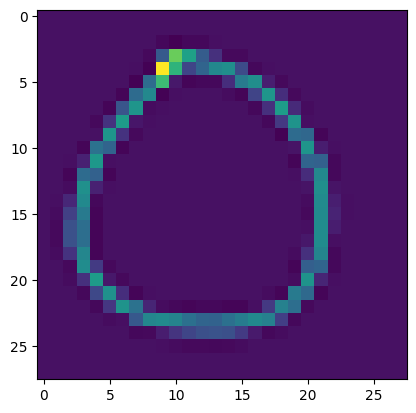

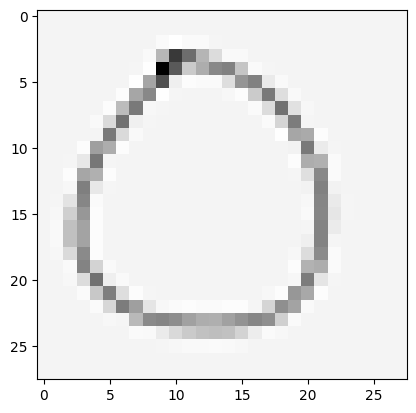

In [ ]:
import matplotlib.pyplot as plt #pip install matplotlib
plt.imshow(x_train[0])
plt.show() ## in order to execute the graph
#change the configuration
plt.imshow(x_train[0], cmap = plt.cm.binary)
plt.show()

# Checking the values of each pixel before Normalization

In [ ]:
print(x_train[0]) ## before normalize

[[[0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]]

 [[0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]]

 [[0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.07058824]
  [0.05490196]
  [0.0

## As images are in Gray level (1 channel ==> 0 to 255), not Colored (RGB)
# Normalizing the data | Pre-Processing Step

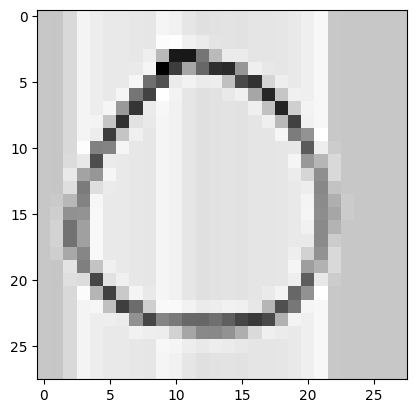

In [ ]:
x_train = tf.keras.utils.normalize (x_train, axis = 1)
x_test = tf.keras.utils.normalize (x_test, axis = 1)
plt.imshow(x_train[0], cmap = plt.cm.binary)


## After Normalization

In [ ]:
print(x_train[0])

[[[0.18898224]
  [0.19294699]
  [0.14551186]
  [0.07776339]
  [0.0958913 ]
  [0.10610286]
  [0.10642693]
  [0.10978059]
  [0.11272258]
  [0.07519542]
  [0.08646255]
  [0.11377375]
  [0.12784942]
  [0.12395824]
  [0.11998667]
  [0.1216744 ]
  [0.11614595]
  [0.11534197]
  [0.11198284]
  [0.10511408]
  [0.09133762]
  [0.07209523]
  [0.18664127]
  [0.18971558]
  [0.18898224]
  [0.18898224]
  [0.18898224]
  [0.18898224]]

 [[0.18898224]
  [0.19294699]
  [0.14551186]
  [0.07776339]
  [0.0958913 ]
  [0.10610286]
  [0.10642693]
  [0.10978059]
  [0.11272258]
  [0.07519542]
  [0.08646255]
  [0.11377375]
  [0.12784942]
  [0.12395824]
  [0.11998667]
  [0.1216744 ]
  [0.11614595]
  [0.11534197]
  [0.11198284]
  [0.10511408]
  [0.09133762]
  [0.07209523]
  [0.18664127]
  [0.18971558]
  [0.18898224]
  [0.18898224]
  [0.18898224]
  [0.18898224]]

 [[0.18898224]
  [0.19294699]
  [0.14551186]
  [0.07776339]
  [0.0958913 ]
  [0.10610286]
  [0.10642693]
  [0.10978059]
  [0.11272258]
  [0.05848533]
  [0.0

In [ ]:
print(y_train[0]) #Lable data set

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## Resizing image to make it suitable for apply Convolution operation

In [ ]:
import numpy as np
IMG_SIZE = 28
x_trainr = np.array(x_train).reshape(-1, IMG_SIZE, IMG_SIZE, 1) ### increasing one dimension for kernel operation
x_testr = np.array(x_test).reshape(-1, IMG_SIZE, IMG_SIZE, 1) ### increasing one dimension for kernel operation
print("Training sample dimension", x_trainr.shape)
print("Testing sample dimension", x_testr.shape)

Training sample dimension (96, 28, 28, 1)
Testing sample dimension (25, 28, 28, 1)


# Creating a Deep Neural Network
### Training on 60,000 of MNIST handwritten dataset

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

In [ ]:
### Creating a nn now
model = Sequential()

#### 1st Convolution layer
model.add(Conv2D(64, (3,3), input_shape = x_trainr.shape[1:])) ## only for 1st Convolution layer to mention input layer size
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size = (2,2)))


#### 2nd Convolution layer
model.add(Conv2D(64, (3,3), input_shape = x_trainr.shape[1:])) ## 2nd Convolution layer
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size = (2,2)))

#### 3rd Convolution layer
model.add(Conv2D(64, (3,3), input_shape = x_trainr.shape[1:])) ## 3rd Convolution layer
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size = (2,2)))

## FUlly connected layer # 1
model.add(Flatten())
model.add(Dense(64))
model.add(Activation("relu"))

## FUlly connected layer # 2
model.add(Dense(64))
model.add(Activation("relu"))

## Last FUlly connected layer # Output must equal to the no. of classes 10 (0-9)
model.add(Dense(10))  # Changed from 64 to 10
model.add(Activation("softmax")) # Activation function for multi-class classification

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 11, 11, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 3, 3, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 1, 1, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,466 (326.04 KB)

 Trainable params: 83,466 (326.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Total training samples = ",len(x_trainr))

Total training samples =  96


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

In [ ]:
model.fit(x_trainr, y_train, epochs = 5, validation_split = 0.3) # Training the model

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 2.7437e-04 - val_accuracy: 0.6207 - val_loss: 4.0205
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 2.9556e-04 - val_accuracy: 0.6207 - val_loss: 4.0186
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 2.8584e-04 - val_accuracy: 0.6207 - val_loss: 4.0182
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 2.7447e-04 - val_accuracy: 0.6207 - val_loss: 4.0189
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 2.8871e-04 - val_accuracy: 0.6207 - val_loss: 4.0241


In [ ]:
test_loss , test_acc = model.evaluate(x_testr, y_test)
print("Test loss on 10,000 test samples: ",test_loss)
print("validation accuracy on 10,000 test samples: ",test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6000 - loss: 2.5507
Test loss on 10,000 test samples:  2.550661325454712
validation accuracy on 10,000 test samples:  0.6000000238418579


In [ ]:
predictions = model.predict([x_testr])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


[[5.75242935e-12 3.11153235e-05 6.56530843e-04 7.88680494e-01
  1.17038418e-07 4.72100692e-10 1.87289745e-13 2.10631624e-01
  4.78898556e-08 1.05468523e-07]
 [1.04451772e-07 1.25939297e-02 1.12108028e-04 4.55823958e-01
  4.02366350e-05 1.54842134e-03 5.23966046e-05 1.93031825e-04
  1.47912335e-02 5.14844596e-01]
 [3.49423426e-05 3.47108798e-05 1.56527767e-05 6.16725393e-10
  1.86632480e-11 1.18252169e-02 3.74669601e-11 1.24577682e-09
  8.60734417e-07 9.88088608e-01]
 [2.63451909e-08 8.80484760e-01 7.34375317e-06 2.89899413e-04
  1.07685159e-08 1.43310928e-04 1.26164196e-07 2.97641467e-08
  1.10784426e-01 8.29010084e-03]
 [3.91962379e-10 1.35450488e-11 3.60916700e-12 7.57421440e-05
  7.36777708e-02 2.69845575e-01 6.53100729e-01 5.66064428e-14
  1.31588685e-03 1.98436296e-03]
 [1.35033389e-07 2.12426272e-08 2.20863541e-08 1.79369195e-07
  2.98490272e-06 7.31625021e-01 6.67060551e-04 2.46919030e-11
  1.44547244e-04 2.67560005e-01]
 [3.99600083e-07 1.49154346e-06 9.60414415e-09 1.65527933e

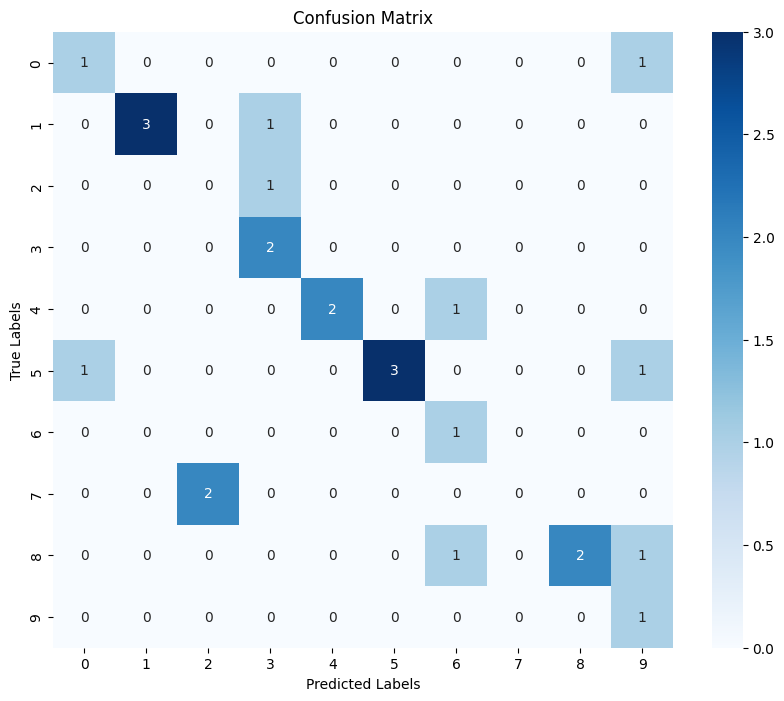

              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       1.00      0.75      0.86         4
           2       0.00      0.00      0.00         1
           3       0.50      1.00      0.67         2
           4       1.00      0.67      0.80         3
           5       1.00      0.60      0.75         5
           6       0.33      1.00      0.50         1
           7       0.00      0.00      0.00         2
           8       1.00      0.50      0.67         4
           9       0.25      1.00      0.40         1

    accuracy                           0.60        25
   macro avg       0.56      0.60      0.51        25
weighted avg       0.74      0.60      0.62        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(predictions)

predicted_labels = np.argmax(predictions, axis=1)  # Get predicted class labels
true_labels = np.argmax(y_test, axis=1)  # Get true class labels
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_labels, predicted_labels)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))  # Adjust figure size if needed
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(true_labels),  # Set x-axis labels
            yticklabels=np.unique(true_labels))  # Set y-axis labels
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

from sklearn.metrics import classification_report



report = classification_report(true_labels, predicted_labels)
print(report)

In [ ]:
print(np.argmax(predictions[0]))

3


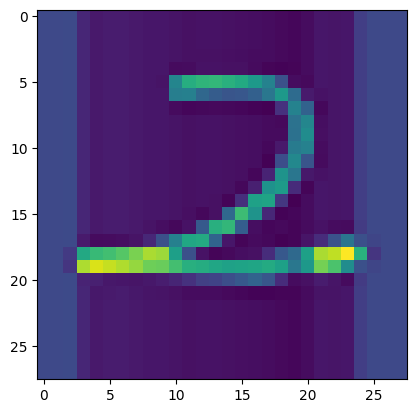

In [ ]:
plt.imshow(x_test[0])

In [ ]:
print(np.argmax(predictions[3]))

1


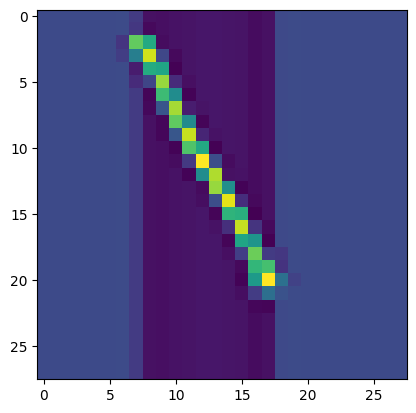

In [ ]:
plt.imshow(x_test[3])

In [ ]:
import cv2 #pip install opencv-python

In [ ]:
# img = cv2.imread('eight.png')

In [ ]:
# plt.imshow(img)

In [ ]:
img.shape

AttributeError: 'Image' object has no attribute 'shape'

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [ ]:
gray.shape

In [ ]:
resized = cv2.resize(gray, (28, 28), interpolation = cv2.INTER_AREA)

In [ ]:
resized.shape

In [ ]:
newimg = tf.keras.utils.normalize (resized, axis = 1)

In [ ]:
newimg = np.array(newimg).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

In [ ]:
newimg.shape

In [ ]:
prediction = model.predict(newimg)

In [ ]:
print(np.argmax(prediction))